In [1]:
import spatioloji_s as sj
import pandas as pd
import numpy as np
import os
import psutil
import matplotlib.pyplot as plt

from spatioloji_s.ccc.run import CCCConfig, run_ccc, run_ccc_multifov, save_ccc_results


from spatioloji_s.spatial import point as spoint
from spatioloji_s.spatial import polygon as spoly
from spatioloji_s.spatial.polygon.neighborhoods import harmonize_niches

In [2]:
mem = psutil.virtual_memory()
print(f"Total memory available: {mem.total / 1024**3:.2f} GB")
cpus = os.cpu_count()
print(f"Total cpu cores available: {cpus}")
print(f"current work directory is {os.getcwd()}")

Total memory available: 251.40 GB
Total cpu cores available: 64
current work directory is /carc/scratch/projects/amitra2016502/spatioloji_s/example


In [3]:
sp = sj.data.spatioloji.from_pickle('my_qc_output/data/filtered_spatioloji.pkl')
# Normalize data
sj.processing.normalize_total(sp, target_sum=1e4, inplace=True)
sj.processing.log_transform(sp, layer='normalized_counts', inplace=True)

# Select highly variable genes
# # of HVG may be less than n_top_genes because we have other cut-off values to filter
sj.processing.highly_variable_genes(sp, n_top_genes=200, inplace=True, min_disp=0, min_mean=0)

# scale data
sj.processing.scale_by_batch_normalization(sp, layer='log_normalized', method='standard', max_value=10.0, 
                                           batch_key='fov', output_layer="fov_scaled",inplace=True)

# Dimensionality reduction
sj.processing.pca(sp, n_comps=50, inplace=True, layer='fov_scaled')
sj.processing.umap(sp, use_pca=True, inplace=True, n_neighbors=30, n_pcs=20, min_dist=0.3)


Loading spatioloji from: my_qc_output/data/filtered_spatioloji.pkl
✓ Loaded: 25,368 cells × 960 genes

Normalizing expression to target sum: 10,000
  Counts per cell - mean: 179, median: 140
  ✓ Normalized 25,368 cells × 960 genes
✓ Added layer 'normalized_counts' (dense, 185.8 MB)

Applying log transformation (base=e)
  ✓ Transformed 25,368 cells × 960 genes
✓ Added layer 'log_normalized' (dense, 185.8 MB)

Identifying highly variable genes (method=seurat)
  Using Seurat method (n_top_genes=200)
  ✓ Selected 200 highly variable genes
    Mean expression range: 0.02 - 2.63

Batch-wise scaling (batch_key='fov', method=standard)
  Found 20 batches
  Clipped values to [-10.0, 10.0]
  ✓ Scaled 25,368 cells × 960 genes across batches
✓ Added layer 'fov_scaled' (dense, 185.8 MB)

Computing PCA (n_comps=50)
  Using 200 highly variable genes
  Running PCA...
  ✓ PCA complete
    Variance explained by first 10 PCs: 17.8%
    Variance explained by all 50 PCs: 39.1%


/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-07 00:07:54.462824: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 00:07:54.516669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 00:07:56.585898: I tensorflow/c


UMAP (n_components=2, n_neighbors=30, min_dist=0.3)
  Using first 20 PCs as input
  Running UMAP...


/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ✓ UMAP complete



Leiden clustering (resolution=0.3, n_neighbors=15)
  Using 200 highly variable genes (out of 960 total)

Leiden clustering (resolution=0.3, n_neighbors=15)
  Using stored PCA (first 50 PCs)
  Building k-NN graph...
  Running Leiden algorithm...
  ✓ Found 9 clusters
    Cluster sizes - min: 185, max: 13448, mean: 2818.7


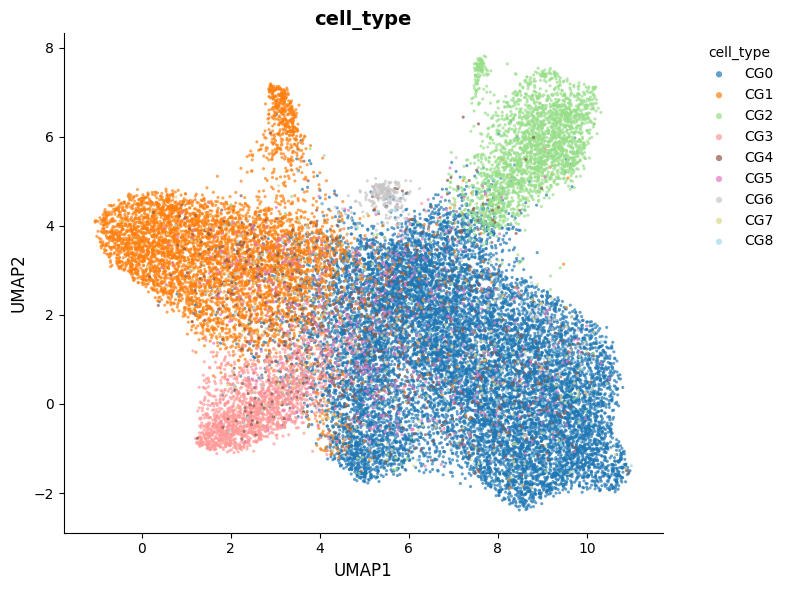

In [4]:
# Clustering
sj.processing.leiden_clustering(sp, resolution=0.3, inplace=True, layer='fov_scaled', use_pca=True)
sp.cell_meta['cell_type'] = ['CG'+str(i) for i in sp.cell_meta.leiden.tolist()]
sj.visualization.plot_umap(sp,
                           color_by='cell_type',
                           show=True)

# ─────────────────────────────────────────────────────────────────────────────
# A. Quickstart — one FOV, built-in LR database
# ─────────────────────────────────────────────────────────────────────────────

In [14]:
sp_fov = sp.subset_by_cells(
    sp.cell_meta.index[sp.cell_meta["fov"] == "004"].tolist()
)
config_whole = CCCConfig(
    cell_type_col   = "cell_type",
    layer           = "log_normalized",
    db_source       = "cellchatdb",
    db_csv_path     = "my_ref/interaction_CellChatDB.csv",
    lr_types        = ["juxtacrine"],
    n_jobs = 24,
    n_permutations = 1000,
)
ccc_results = run_ccc(sp_fov, config_whole)




Subsetting by cells: 1963 cells requested

Initializing spatioloji
[1/11] Master indices: 1,963 cells × 960 genes
[2/11] Expression matrix: sparse (2.7 MB)
[3/10] Cell metadata: 84 columns
[4/11] Gene metadata: 11 columns
[5/11] Spatial coordinates: 1963 cells
[6/11] Polygons: 41103 vertices for 1963 cells
[7/11] Images: 1 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              1,963
  Genes:              960
  FOVs:               1
  Images:             1 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    10.5 MB

✓ Created subset: 1963 cells, 1 FOVs
  Layers subsetted (cell axis): ['normalized_counts', 'log_normalized', 'fov_scaled']
  Embeddings subsetted: ['X_pca', 'X_pca_variance', 'X_pca_variance_ratio', 'X_umap']

════════════════════════════════════════════════════════════
spatioloji 

/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/ccc/layer2.py:328: RuntimeWarning: invalid value encountered in subtract
  if np.max(np.abs(log_u - log_u_old)) < tol:


In [16]:
ccc_results


{'config': CCCConfig(cell_type_col='cell_type', layer='log_normalized', db_source='cellchatdb', db_csv_path='my_ref/interaction_CellChatDB.csv', lr_types=['juxtacrine'], min_pct=0.05, n_permutations=1000, alpha_moran=0.05, alpha_lag=0.05, min_rho=0.05, n_jobs=24, secreted_radius=100.0, ecm_radius=200.0, cross_fov_secreted=False, cross_fov_ecm=False, min_weight=0.001, ot_reg=0.1, ot_iter=50, hub_percentile=90.0, top_k_l2=None, n_permutations_contrast=1000, z_thresh=1.96, K=None, k_range=range(2, 11), lambda_reg=0.1, coord_type='global', seed=42, verbose=True),
 'sp_summary': {'fov_id': '004',
  'n_cells': 1963,
  'n_genes': 960,
  'n_cell_types': 9},
 'lr_pairs': [LRPair('APP_CD74', ligand='APP', receptor='CD74', type='juxtacrine', pathway='APP'),
  LRPair('PTPRC_MRC1', ligand='PTPRC', receptor='MRC1', type='juxtacrine', pathway='CD45'),
  LRPair('CD80_CD274', ligand='CD80', receptor='CD274', type='juxtacrine', pathway='CD80'),
  LRPair('CD80_CD28', ligand='CD80', receptor='CD28', type=